<a href="https://colab.research.google.com/github/minadjordjevic/Language-Classification/blob/main/language_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
LANGUAGES = {
    "el": ["babel-briefings-v1-gr.json"],
    "en": [
        "babel-briefings-v1-ie.json",
        "babel-briefings-v1-in.json",
        "babel-briefings-v1-my.json",
        "babel-briefings-v1-ng.json",
        "babel-briefings-v1-nz.json",
        "babel-briefings-v1-ph.json",
    ],
    "fr": ["babel-briefings-v1-ma.json"],
    "he": ["babel-briefings-v1-il.json"],
    "hu": ["babel-briefings-v1-hu.json"],
    "id": ["babel-briefings-v1-id.json"],
    "it": ["babel-briefings-v1-it.json"],
    "ja": ["babel-briefings-v1-jp.json"],
    "ko": ["babel-briefings-v1-kr.json"],
    "lt": ["babel-briefings-v1-lt.json"],
    "lv": ["babel-briefings-v1-lv.json"],
    "zh": ["babel-briefings-v1-hk.json"],
}

SAMPLES_PER_LANGUAGE = 5000

print("Broj jezika:", len(LANGUAGES))
print("Primera po jeziku:", SAMPLES_PER_LANGUAGE)
print("Ukupno primera:", len(LANGUAGES) * SAMPLES_PER_LANGUAGE)

Broj jezika: 12
Primera po jeziku: 5000
Ukupno primera: 60000


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    json_files = [f for f in files if f.endswith(".json")]

    if json_files:
        print("Folder:", root)
        print("JSON fajlovi:", json_files[:10])
        print()

Folder: /content/drive/MyDrive/vip/vip
JSON fajlovi: ['babel-briefings-v1-il.json', 'babel-briefings-v1-in.json', 'babel-briefings-v1-it.json', 'babel-briefings-v1-jp.json', 'babel-briefings-v1-kr.json', 'babel-briefings-v1-lt.json', 'babel-briefings-v1-lv.json', 'babel-briefings-v1-ma.json', 'babel-briefings-v1-mx.json', 'babel-briefings-v1-my.json']



In [4]:
import json

DATA_PATH = "/content/drive/MyDrive/vip/vip"

file_path = f"{DATA_PATH}/babel-briefings-v1-il.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))
print("Broj zapisa:", len(data))
print("Prvi zapis:")
print(data[0])

<class 'list'>
Broj zapisa: 67794
Prvi zapis:
{'author': None, 'title': 'עמנואל מקרון בסיור בביירות: "בלי רפורמות, לבנון תסבול" - מקור ראשון', 'description': None, 'url': 'https://www.makorrishon.co.il/news/254161/', 'urlToImage': None, 'publishedAt': '2020-08-07T05:37:50Z', 'content': None, 'instances': [{'collectedAt': '2020-08-07T18:53:00Z', 'location': 'il', 'category': 'general'}], 'source-id': None, 'source-name': 'Makorrishon.co.il', 'ID': 131, 'en-title': 'Emmanuel Macron on tour in Beirut: "Without reforms, Lebanon will suffer" - first source', 'language': 'he'}


In [5]:
import pandas as pd

df_test = pd.DataFrame(data)

print("Broj zapisa:", len(df_test))
print("\nKolone:")
print(df_test.columns.tolist())

print("\nNedostajuće vrednosti:")
print(df_test[["title", "description", "content", "language"]].isnull().sum())

print("\nJezik:")
print(df_test["language"].value_counts())

Broj zapisa: 67794

Kolone:
['author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content', 'instances', 'source-id', 'source-name', 'ID', 'en-title', 'language', 'en-description', 'en-content']

Nedostajuće vrednosti:
title              0
description     5047
content        10075
language           0
dtype: int64

Jezik:
language
he    67794
Name: count, dtype: int64


In [6]:
import random

all_records = []

for language, files in LANGUAGES.items():
    print(f"Učitavanje jezika: {language}")

    language_records = []

    for file_name in files:
        file_path = f"{DATA_PATH}/{file_name}"

        with open(file_path, "r", encoding="utf-8") as f:
            records = json.load(f)

        language_records.extend(records)

    print(f"  Ukupno dostupno: {len(language_records)}")

    # Nasumično biramo 5000 primera
    random.seed(42)
    selected_records = random.sample(
        language_records,
        SAMPLES_PER_LANGUAGE
    )

    # Dodajemo labelu jezika
    for record in selected_records:
        all_records.append({
            "text": record["title"],
            "language": language
        })

print("\nUkupno izabranih primera:", len(all_records))

Učitavanje jezika: el
  Ukupno dostupno: 119940
Učitavanje jezika: en
  Ukupno dostupno: 521660
Učitavanje jezika: fr
  Ukupno dostupno: 91643
Učitavanje jezika: he
  Ukupno dostupno: 67794
Učitavanje jezika: hu
  Ukupno dostupno: 73509
Učitavanje jezika: id
  Ukupno dostupno: 131252
Učitavanje jezika: it
  Ukupno dostupno: 129005
Učitavanje jezika: ja
  Ukupno dostupno: 118475
Učitavanje jezika: ko
  Ukupno dostupno: 83090
Učitavanje jezika: lt
  Ukupno dostupno: 34719
Učitavanje jezika: lv
  Ukupno dostupno: 40006
Učitavanje jezika: zh
  Ukupno dostupno: 82324

Ukupno izabranih primera: 60000


In [7]:
df = pd.DataFrame(all_records)

print("Dimenzije dataseta:", df.shape)

print("\nPrvih 5 primera:")
display(df.head())

print("\nBroj primera po jeziku:")
print(df["language"].value_counts().sort_index())

Dimenzije dataseta: (60000, 2)

Prvih 5 primera:


,text,language
0,ΠΑΟΚ: ﻿Τα δεδομένα με Ντεϊόλα και ο... Ραϊόλα ...,el
1,Βίντεο: O Βλαδίμηρος Κυριακίδης είχε παίξει το...,el
2,Linuxfx 10.5 το Linux που μοιάζει ακριβώς με W...,el
3,Ευκαιρία να αποκτήσετε μια από τις καλύτερες M...,el
4,«Προβλήματα θα υπάρχουν και στη μετά Covid επο...,el



Broj primera po jeziku:
language
el    5000
en    5000
fr    5000
he    5000
hu    5000
id    5000
it    5000
ja    5000
ko    5000
lt    5000
lv    5000
zh    5000
Name: count, dtype: int64


In [8]:
print("Nedostajuće vrednosti:")
print(df.isnull().sum())

print("\nBroj duplikata:")
print(df.duplicated().sum())

print("\nBroj duplikata samo u tekstu:")
print(df["text"].duplicated().sum())

Nedostajuće vrednosti:
text        0
language    0
dtype: int64

Broj duplikata:
136

Broj duplikata samo u tekstu:
136


In [9]:
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Broj primera nakon uklanjanja duplikata:", len(df))

print("\nBroj primera po jeziku:")
print(df["language"].value_counts().sort_index())

Broj primera nakon uklanjanja duplikata: 59864

Broj primera po jeziku:
language
el    4998
en    4999
fr    4984
he    4987
hu    4994
id    5000
it    4991
ja    4998
ko    4972
lt    4967
lv    4982
zh    4992
Name: count, dtype: int64


In [10]:
df["text_length"] = df["text"].str.len()

print("Statistika dužine tekstova:")
print(df["text_length"].describe())

Statistika dužine tekstova:
count    59864.000000
mean        75.963885
std         28.517574
min          9.000000
25%         55.000000
50%         75.000000
75%         92.000000
max        330.000000
Name: text_length, dtype: float64


In [11]:
print("5 najkraćih tekstova:")
display(df.nsmallest(5, "text_length")[["text", "language", "text_length"]])

print("\n5 najdužih tekstova:")
display(df.nlargest(5, "text_length")[["text", "language", "text_length"]])

5 najkraćih tekstova:


,text,language,text_length
40453,뉴시스 - 뉴시스,ko,9
57073,乘車付款 - PCM,zh,10
40304,비즈한국 - 비즈한국,ko,11
40451,전남일보 - 전남일보,ko,11
41933,보안뉴스 - 보안뉴스,ko,11



5 najdužih tekstova:


,text,language,text_length
12382,Part de marché mondiale de Lumière d'alarme – ...,fr,330
12307,Marché mondial du Tuyaux tubulaires pour puits...,fr,312
11046,Taille du marché Instrument d'essai acide nucl...,fr,303
12308,Logiciels spéciaux Education Marché 2020 Taill...,fr,302
11822,Marché Sulfure de sodium (Cas 1313-82-2) 2020 ...,fr,298


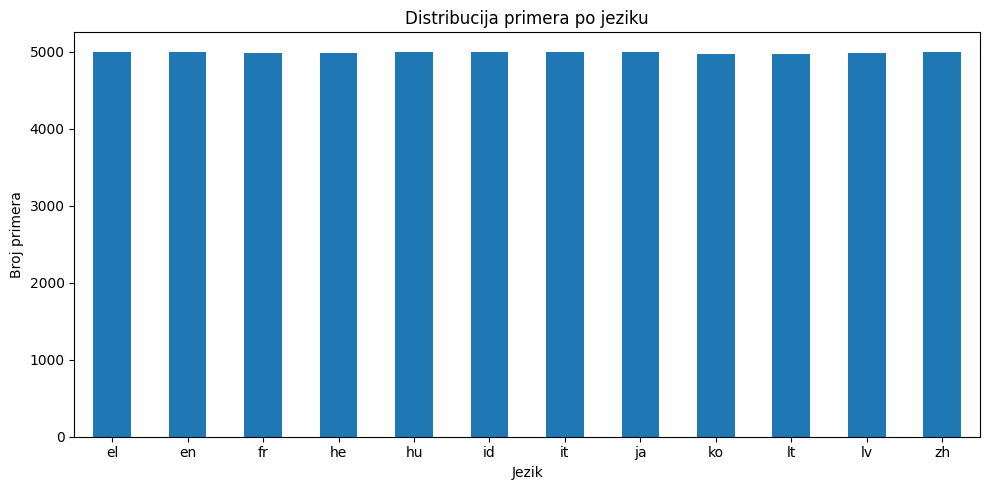

In [12]:
import matplotlib.pyplot as plt

language_counts = df["language"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
language_counts.plot(kind="bar")

plt.title("Distribucija primera po jeziku")
plt.xlabel("Jezik")
plt.ylabel("Broj primera")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

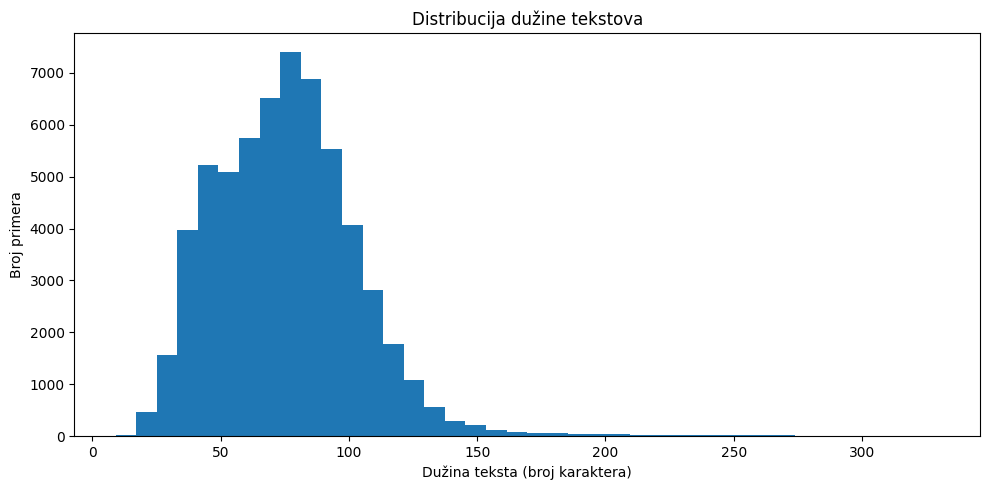

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(df["text_length"], bins=40)

plt.title("Distribucija dužine tekstova")
plt.xlabel("Dužina teksta (broj karaktera)")
plt.ylabel("Broj primera")

plt.tight_layout()
plt.show()

In [14]:
avg_length_by_language = (
    df.groupby("language")["text_length"]
      .mean()
      .sort_values(ascending=False)
)

print("Prosečna dužina teksta po jeziku:")
print(avg_length_by_language)

Prosečna dužina teksta po jeziku:
language
fr    98.621990
it    92.788620
en    89.396079
lt    89.214012
lv    86.978322
id    86.602400
el    85.829132
hu    75.344013
he    64.283938
ja    54.265106
ko    45.239541
zh    42.975361
Name: text_length, dtype: float64


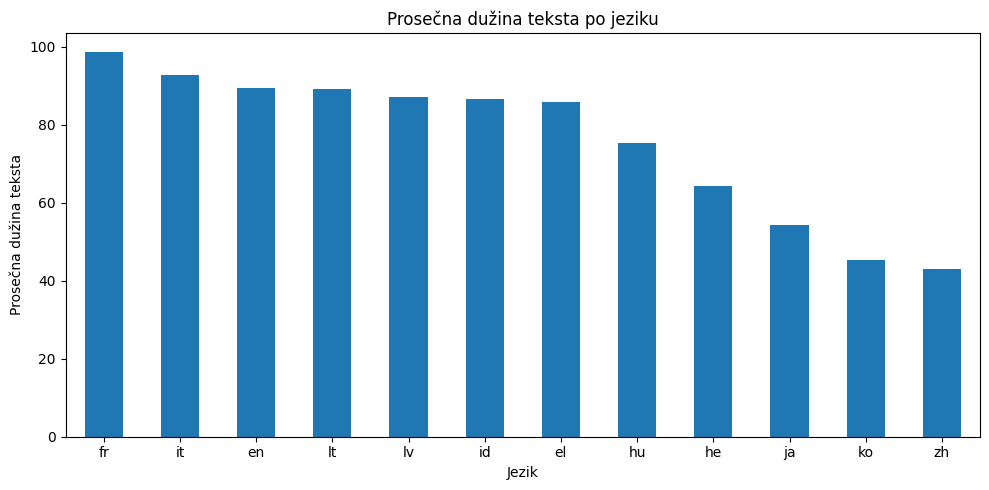

In [15]:
plt.figure(figsize=(10, 5))

avg_length_by_language.plot(kind="bar")

plt.title("Prosečna dužina teksta po jeziku")
plt.xlabel("Jezik")
plt.ylabel("Prosečna dužina teksta")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
df = df[["text", "language"]].copy()

print("Konačne kolone:")
print(df.columns.tolist())

print("\nDimenzije:")
print(df.shape)

display(df.head())

Konačne kolone:
['text', 'language']

Dimenzije:
(59864, 2)


,text,language
0,ΠΑΟΚ: ﻿Τα δεδομένα με Ντεϊόλα και ο... Ραϊόλα ...,el
1,Βίντεο: O Βλαδίμηρος Κυριακίδης είχε παίξει το...,el
2,Linuxfx 10.5 το Linux που μοιάζει ακριβώς με W...,el
3,Ευκαιρία να αποκτήσετε μια από τις καλύτερες M...,el
4,«Προβλήματα θα υπάρχουν και στη μετά Covid επο...,el


In [17]:
import os

os.makedirs("src", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/metrics", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("configs", exist_ok=True)

print("Project folders created.")

Project folders created.


In [18]:
%%writefile src/data.py

import json
import random
from pathlib import Path


LANGUAGES = {
    "el": ["babel-briefings-v1-gr.json"],
    "en": [
        "babel-briefings-v1-ie.json",
        "babel-briefings-v1-in.json",
        "babel-briefings-v1-my.json",
        "babel-briefings-v1-ng.json",
        "babel-briefings-v1-nz.json",
        "babel-briefings-v1-ph.json",
    ],
    "fr": ["babel-briefings-v1-ma.json"],
    "he": ["babel-briefings-v1-il.json"],
    "hu": ["babel-briefings-v1-hu.json"],
    "id": ["babel-briefings-v1-id.json"],
    "it": ["babel-briefings-v1-it.json"],
    "ja": ["babel-briefings-v1-jp.json"],
    "ko": ["babel-briefings-v1-kr.json"],
    "lt": ["babel-briefings-v1-lt.json"],
    "lv": ["babel-briefings-v1-lv.json"],
    "zh": ["babel-briefings-v1-hk.json"],
}


def load_language_data(
    data_path,
    samples_per_language=5000,
    seed=42
):
    """
    Loads a balanced subset of news titles for each language.
    """

    data_path = Path(data_path)
    all_records = []

    for language, files in LANGUAGES.items():
        language_records = []

        for file_name in files:
            file_path = data_path / file_name

            with open(file_path, "r", encoding="utf-8") as f:
                records = json.load(f)

            language_records.extend(records)

        rng = random.Random(seed)

        selected_records = rng.sample(
            language_records,
            samples_per_language
        )

        for record in selected_records:
            title = record.get("title")

            if title is not None and str(title).strip():
                all_records.append({
                    "text": str(title).strip(),
                    "language": language
                })

    return all_records

Writing src/data.py


In [19]:
from src.data import load_language_data

DATA_PATH = "/content/drive/MyDrive/vip/vip"

records = load_language_data(
    data_path=DATA_PATH,
    samples_per_language=5000,
    seed=42
)

print("Ukupno učitanih primera:", len(records))
print("\nPrvi primer:")
print(records[0])

Ukupno učitanih primera: 60000

Prvi primer:
{'text': 'ΠΑΟΚ: \ufeffΤα δεδομένα με Ντεϊόλα και ο... Ραϊόλα - MetroSport.gr', 'language': 'el'}


In [20]:
import os

print(os.path.exists("src/data.py"))
print(os.path.abspath("src/data.py"))

True
/content/src/data.py


In [24]:
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/preprocessing.py -O src/preprocessing.py

print("preprocessing.py je preuzet.")

preprocessing.py je preuzet.


In [25]:
import importlib
import src.preprocessing

importlib.reload(src.preprocessing)

from src.preprocessing import create_dataframe

print("preprocessing.py uspešno učitan.")

preprocessing.py uspešno učitan.


In [26]:
from src.data import load_language_data
from src.preprocessing import create_dataframe

DATA_PATH = "/content/drive/MyDrive/vip/vip"

records = load_language_data(
    data_path=DATA_PATH,
    samples_per_language=5000,
    seed=42
)

df = create_dataframe(records)

print("Raw examples:", len(records))
print("After preprocessing:", len(df))

print("\nExamples per language:")
print(df["language"].value_counts().sort_index())

Raw examples: 60000
After preprocessing: 59864

Examples per language:
language
el    4998
en    4999
fr    4984
he    4987
hu    4994
id    5000
it    4991
ja    4998
ko    4972
lt    4967
lv    4982
zh    4992
Name: count, dtype: int64


In [27]:
from src.preprocessing import create_train_val_test_split

train_df, val_df, test_df = create_train_val_test_split(
    df,
    test_size=0.10,
    validation_size=0.10,
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Train: 47890
Validation: 5987
Test: 5987
Total: 59864


In [28]:
print("TRAIN:")
print(train_df["language"].value_counts().sort_index())

print("\nVALIDATION:")
print(val_df["language"].value_counts().sort_index())

print("\nTEST:")
print(test_df["language"].value_counts().sort_index())

TRAIN:
language
el    3998
en    3999
fr    3987
he    3989
hu    3995
id    4000
it    3993
ja    3998
ko    3978
lt    3973
lv    3986
zh    3994
Name: count, dtype: int64

VALIDATION:
language
el    500
en    500
fr    499
he    499
hu    499
id    500
it    499
ja    500
ko    497
lt    497
lv    498
zh    499
Name: count, dtype: int64

TEST:
language
el    500
en    500
fr    498
he    499
hu    500
id    500
it    499
ja    500
ko    497
lt    497
lv    498
zh    499
Name: count, dtype: int64


In [29]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Fitujemo encoder samo na svim poznatim klasama
label_encoder.fit(df["language"])

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label"] = label_encoder.transform(train_df["language"])
val_df["label"] = label_encoder.transform(val_df["language"])
test_df["label"] = label_encoder.transform(test_df["language"])

print("Mapiranje jezika:")

for language, label in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{language} -> {label}")

Mapiranje jezika:
el -> 0
en -> 1
fr -> 2
he -> 3
hu -> 4
id -> 5
it -> 6
ja -> 7
ko -> 8
lt -> 9
lv -> 10
zh -> 11


In [1]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Transformers: 5.15.0
CUDA available: True
GPU: Tesla T4


In [3]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer uspešno učitan.")
print("Veličina vokabulara:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Tokenizer uspešno učitan.
Veličina vokabulara: 119547


In [5]:
import os

os.makedirs("src", exist_ok=True)

!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/data.py -O src/data.py
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/preprocessing.py -O src/preprocessing.py
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/dataset.py -O src/dataset.py
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/models.py -O src/models.py

print("src fajlovi uspešno preuzeti:")
print(os.listdir("src"))

src fajlovi uspešno preuzeti:
['preprocessing.py', 'models.py', 'dataset.py', 'data.py']


In [12]:
!rm -f src/data.py
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/data.py -O src/data.py

with open("src/data.py", "r", encoding="utf-8") as f:
    first_line = f.readline()

print("PRVA LINIJA:", repr(first_line))

PRVA LINIJA: 'import json\n'


In [13]:
from src.data import load_language_data

print("data.py uspešno učitan.")

data.py uspešno učitan.


In [15]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [16]:
import os

DATA_PATH = "/content/drive/MyDrive/vip/vip"

print("Folder postoji:", os.path.exists(DATA_PATH))
print("Broj JSON fajlova:", len([
    f for f in os.listdir(DATA_PATH)
    if f.endswith(".json")
]))

Folder postoji: True
Broj JSON fajlova: 21


In [18]:
from src.data import load_language_data
from src.preprocessing import create_dataframe, create_train_val_test_split

DATA_PATH = "/content/drive/MyDrive/vip/vip"

records = load_language_data(
    data_path=DATA_PATH,
    samples_per_language=5000,
    seed=42
)

df = create_dataframe(records)

train_df, val_df, test_df = create_train_val_test_split(
    df,
    test_size=0.10,
    validation_size=0.10,
    random_state=42
)

print("Raw:", len(records))
print("Clean:", len(df))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Raw: 60000
Clean: 59864
Train: 47890
Validation: 5987
Test: 5987


In [19]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(df["language"])

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label"] = label_encoder.transform(train_df["language"])
val_df["label"] = label_encoder.transform(val_df["language"])
test_df["label"] = label_encoder.transform(test_df["language"])

print("Broj klasa:", len(label_encoder.classes_))
print("Klase:", list(label_encoder.classes_))

Broj klasa: 12
Klase: ['el', 'en', 'fr', 'he', 'hu', 'id', 'it', 'ja', 'ko', 'lt', 'lv', 'zh']


In [27]:
!rm -f src/dataset.py
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/dataset.py -O src/dataset.py

with open("src/dataset.py", "r", encoding="utf-8") as f:
    content = f.read()

print(content[:300])

import torch
from torch.utils.data import Dataset


class LanguageDataset(Dataset):
    """
    PyTorch Dataset for multilingual language classification.
    """

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length=128
    ):
        self.texts = list


In [28]:
import sys

if "src.dataset" in sys.modules:
    del sys.modules["src.dataset"]

from src.dataset import LanguageDataset

print("LanguageDataset uspešno učitan.")

LanguageDataset uspešno učitan.


In [29]:
train_dataset = LanguageDataset(
    texts=train_df["text"],
    labels=train_df["label"],
    tokenizer=tokenizer,
    max_length=128
)

val_dataset = LanguageDataset(
    texts=val_df["text"],
    labels=val_df["label"],
    tokenizer=tokenizer,
    max_length=128
)

test_dataset = LanguageDataset(
    texts=test_df["text"],
    labels=test_df["label"],
    tokenizer=tokenizer,
    max_length=128
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 47890
Validation: 5987
Test: 5987


In [30]:
sample = train_dataset[0]

print("Keys:", sample.keys())
print("input_ids shape:", sample["input_ids"].shape)
print("attention_mask shape:", sample["attention_mask"].shape)
print("label:", sample["labels"].item())

Keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
input_ids shape: torch.Size([128])
attention_mask shape: torch.Size([128])
label: 2


In [31]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2994
Validation batches: 375
Test batches: 375


In [32]:
batch = next(iter(train_loader))

print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("labels:", batch["labels"].shape)

input_ids: torch.Size([16, 128])
attention_mask: torch.Size([16, 128])
labels: torch.Size([16])


In [33]:
import torch
from src.models import LanguageClassifier

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LanguageClassifier(
    model_name="bert-base-multilingual-cased",
    num_classes=12,
    dropout=0.1
)

model = model.to(DEVICE)

print("Device:", DEVICE)
print("Model successfully loaded.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Model successfully loaded.


In [34]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

Total parameters: 177,862,668
Trainable parameters: 177,862,668


In [35]:
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/train.py -O src/train.py

print("train.py preuzet.")

train.py preuzet.


In [36]:
import sys

if "src.train" in sys.modules:
    del sys.modules["src.train"]

from src.train import train_one_epoch, evaluate

print("train.py uspešno učitan.")

train.py uspešno učitan.


In [37]:
from torch.optim import AdamW

LEARNING_RATE = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)

Optimizer: AdamW
Learning rate: 2e-05


In [39]:
from torch.utils.data import DataLoader, Subset

TEST_SAMPLES = 160

test_subset = Subset(train_dataset, range(TEST_SAMPLES))

test_train_loader = DataLoader(
    test_subset,
    batch_size=16,
    shuffle=True
)

print("Test batch-eva:", len(test_train_loader))

Test batch-eva: 10


In [40]:
result = train_one_epoch(
    model=model,
    data_loader=test_train_loader,
    optimizer=optimizer,
    scheduler=None,
    device=DEVICE
)

print("Rezultat mini testa:")
print(result)

Rezultat mini testa:
{'loss': 1.6856018900871277, 'accuracy': 0.66875, 'f1': 0.6525371912288749, 'time': 3.6532607078552246}


In [1]:
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/utils.py -O src/utils.py

print("utils.py preuzet.")

src/utils.py: No such file or directory
utils.py preuzet.


In [4]:
import os
import sys

os.makedirs("/content/src", exist_ok=True)

files = [
    "data.py",
    "preprocessing.py",
    "dataset.py",
    "models.py",
    "train.py",
    "utils.py"
]

for file in files:
    url = f"https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/{file}"
    path = f"/content/src/{file}"

    !wget -q "$url" -O "$path"

sys.path.insert(0, "/content")

print("Svi src fajlovi su preuzeti:")
print(os.listdir("/content/src"))

Svi src fajlovi su preuzeti:
['data.py', 'train.py', 'preprocessing.py', 'dataset.py', 'utils.py', 'models.py']


In [5]:
from src.utils import set_seed, get_device

set_seed(42)

DEVICE = get_device()

print("Seed:", 42)
print("Device:", DEVICE)

Seed: 42
Device: cuda


In [6]:
import torch
import transformers
import sklearn
import numpy
import pandas

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Scikit-learn:", sklearn.__version__)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Transformers: 5.15.0
Scikit-learn: 1.6.1
NumPy: 2.1.3
Pandas: 2.2.3
CUDA available: True
GPU: Tesla T4


In [7]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
from src.data import load_language_data
from src.preprocessing import create_dataframe, create_train_val_test_split

DATA_PATH = "/content/drive/MyDrive/vip/vip"

records = load_language_data(
    data_path=DATA_PATH,
    samples_per_language=5000,
    seed=42
)

df = create_dataframe(records)

train_df, val_df, test_df = create_train_val_test_split(
    df,
    test_size=0.10,
    validation_size=0.10,
    random_state=42
)

print("Raw:", len(records))
print("Clean:", len(df))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Raw: 60000
Clean: 59864
Train: 47890
Validation: 5987
Test: 5987


In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(df["language"])

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label"] = label_encoder.transform(train_df["language"])
val_df["label"] = label_encoder.transform(val_df["language"])
test_df["label"] = label_encoder.transform(test_df["language"])

print("Classes:", list(label_encoder.classes_))

Classes: ['el', 'en', 'fr', 'he', 'hu', 'id', 'it', 'ja', 'ko', 'lt', 'lv', 'zh']


In [10]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer uspešno učitan.")
print("Veličina vokabulara:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Tokenizer uspešno učitan.
Veličina vokabulara: 119547


In [11]:
from src.dataset import LanguageDataset
from torch.utils.data import DataLoader

MAX_LENGTH = 128
BATCH_SIZE = 16

train_dataset = LanguageDataset(
    train_df["text"],
    train_df["label"],
    tokenizer,
    MAX_LENGTH
)

val_dataset = LanguageDataset(
    val_df["text"],
    val_df["label"],
    tokenizer,
    MAX_LENGTH
)

test_dataset = LanguageDataset(
    test_df["text"],
    test_df["label"],
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2994
Validation batches: 375
Test batches: 375


In [12]:
from src.models import LanguageClassifier

model = LanguageClassifier(
    model_name=MODEL_NAME,
    num_classes=12,
    dropout=0.1
)

model = model.to(DEVICE)

print("Model loaded on:", DEVICE)

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on: cuda


In [13]:
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/experiment.py -O src/experiment.py

print("experiment.py preuzet.")

experiment.py preuzet.


In [15]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132

In [16]:
import mlflow

print("MLflow:", mlflow.__version__)

MLflow: 3.15.1


In [17]:
from src.experiment import run_experiment

print("Experiment runner uspešno učitan.")

Experiment runner uspešno učitan.


In [18]:
from src.utils import set_seed

set_seed(42)

print("Seed postavljen na 42.")

Seed postavljen na 42.


In [20]:
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/train.py -O /content/src/train.py
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/experiment.py -O /content/src/experiment.py

print("train.py i experiment.py ažurirani.")

train.py i experiment.py ažurirani.


In [21]:
from itertools import islice
from torch.utils.data import DataLoader, Subset

BENCHMARK_SAMPLES = 1600  # 100 batch-eva × 16

benchmark_dataset = Subset(
    train_dataset,
    range(BENCHMARK_SAMPLES)
)

benchmark_loader = DataLoader(
    benchmark_dataset,
    batch_size=16,
    shuffle=False
)

print("Benchmark batch-eva:", len(benchmark_loader))

Benchmark batch-eva: 100


In [22]:
from src.utils import set_seed
from src.models import LanguageClassifier
import torch

set_seed(42)

benchmark_model = LanguageClassifier(
    model_name="bert-base-multilingual-cased",
    num_classes=12,
    dropout=0.1
).to(DEVICE)

benchmark_optimizer = torch.optim.AdamW(
    benchmark_model.parameters(),
    lr=2e-5
)

print("Benchmark model spreman.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Benchmark model spreman.


In [24]:
from src.train import train_one_epoch, evaluate

print("train_one_epoch uspešno učitan.")

train_one_epoch uspešno učitan.


In [26]:
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/train.py -O /content/src/train.py
print("train.py ponovo preuzet.")

train.py ponovo preuzet.


In [27]:
import importlib
import src.train

importlib.reload(src.train)

from src.train import train_one_epoch, evaluate

print("Nova verzija train.py učitana.")

Nova verzija train.py učitana.


In [28]:
import inspect

print(inspect.signature(train_one_epoch))

(model, data_loader, optimizer, scheduler, device, epoch=None)


In [29]:
benchmark_result = train_one_epoch(
    model=benchmark_model,
    data_loader=benchmark_loader,
    optimizer=benchmark_optimizer,
    scheduler=None,
    device=DEVICE,
    epoch="BENCHMARK"
)

print("\nBenchmark rezultat:")
print(benchmark_result)

Epoch BENCHMARK:   0%|          | 0/100 [00:00<?, ?it/s]


Benchmark rezultat:
{'loss': 0.5892161230836064, 'accuracy': 0.87, 'f1': 0.8731435128217612, 'time': 38.43260931968689}


In [30]:
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/experiment.py -O /content/src/experiment.py

import importlib
import src.experiment

importlib.reload(src.experiment)

from src.experiment import run_experiment

print("experiment.py učitan.")

experiment.py učitan.


In [31]:
set_seed(42)

experiment_1_model, experiment_1_results = run_experiment(
    experiment_name="experiment_1_baseline",
    model_name="bert-base-multilingual-cased",
    num_classes=12,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=DEVICE,
    learning_rate=2e-5,
    dropout=0.1,
    epochs=2,
)

print("\nExperiment 1 završen.")
print(experiment_1_results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1:   0%|          | 0/2994 [00:00<?, ?it/s]

Epoch 1/2 | Train Loss: 0.0332 | Train Acc: 0.9926 | Val Loss: 0.0084 | Val Acc: 0.9983 | Val F1: 0.9983


Epoch 2:   0%|          | 0/2994 [00:00<?, ?it/s]

Epoch 2/2 | Train Loss: 0.0098 | Train Acc: 0.9982 | Val Loss: 0.0093 | Val Acc: 0.9980 | Val F1: 0.9980

Test results:
Accuracy: 0.9983
F1: 0.9983
Training time: 2567.79s
Inference time: 52.97s

Experiment 1 završen.
{'loss': 0.008855557188896152, 'accuracy': 0.9983297143811591, 'f1': 0.9983306504379751, 'time': 52.968437910079956, 'predictions': [np.int64(3), np.int64(10), np.int64(6), np.int64(8), np.int64(5), np.int64(3), np.int64(2), np.int64(9), np.int64(8), np.int64(7), np.int64(10), np.int64(11), np.int64(10), np.int64(1), np.int64(11), np.int64(2), np.int64(0), np.int64(9), np.int64(11), np.int64(8), np.int64(6), np.int64(11), np.int64(1), np.int64(7), np.int64(6), np.int64(8), np.int64(5), np.int64(5), np.int64(10), np.int64(11), np.int64(5), np.int64(5), np.int64(10), np.int64(2), np.int64(8), np.int64(3), np.int64(2), np.int64(4), np.int64(10), np.int64(11), np.int64(11), np.int64(9), np.int64(7), np.int64(3), np.int64(5), np.int64(7), np.int64(4), np.int64(0), np.int64(4),

In [32]:
print("experiment_1_model" in globals())
print("experiment_1_results" in globals())

True
True


In [33]:
print("Experiment 1 rezultati:")
print(experiment_1_results)

Experiment 1 rezultati:
{'loss': 0.008855557188896152, 'accuracy': 0.9983297143811591, 'f1': 0.9983306504379751, 'time': 52.968437910079956, 'predictions': [np.int64(3), np.int64(10), np.int64(6), np.int64(8), np.int64(5), np.int64(3), np.int64(2), np.int64(9), np.int64(8), np.int64(7), np.int64(10), np.int64(11), np.int64(10), np.int64(1), np.int64(11), np.int64(2), np.int64(0), np.int64(9), np.int64(11), np.int64(8), np.int64(6), np.int64(11), np.int64(1), np.int64(7), np.int64(6), np.int64(8), np.int64(5), np.int64(5), np.int64(10), np.int64(11), np.int64(5), np.int64(5), np.int64(10), np.int64(2), np.int64(8), np.int64(3), np.int64(2), np.int64(4), np.int64(10), np.int64(11), np.int64(11), np.int64(9), np.int64(7), np.int64(3), np.int64(5), np.int64(7), np.int64(4), np.int64(0), np.int64(4), np.int64(8), np.int64(3), np.int64(4), np.int64(11), np.int64(0), np.int64(8), np.int64(10), np.int64(6), np.int64(1), np.int64(5), np.int64(3), np.int64(0), np.int64(3), np.int64(8), np.int64(

In [34]:
print("Loss:", experiment_1_results["loss"])
print("Accuracy:", experiment_1_results["accuracy"])
print("F1:", experiment_1_results["f1"])
print("Time:", experiment_1_results["time"])

Loss: 0.008855557188896152
Accuracy: 0.9983297143811591
F1: 0.9983306504379751
Time: 52.968437910079956


In [35]:
from sklearn.metrics import classification_report

report = classification_report(
    experiment_1_results["labels"],
    experiment_1_results["predictions"],
    target_names=[
        "el", "en", "fr", "he",
        "hu", "id", "it", "ja",
        "ko", "lt", "lv", "zh"
    ],
    digits=4
)

print(report)

              precision    recall  f1-score   support

          el     1.0000    1.0000    1.0000       500
          en     0.9940    0.9980    0.9960       500
          fr     0.9960    0.9960    0.9960       498
          he     1.0000    1.0000    1.0000       499
          hu     1.0000    0.9960    0.9980       500
          id     1.0000    0.9960    0.9980       500
          it     0.9960    0.9960    0.9960       499
          ja     0.9960    1.0000    0.9980       500
          ko     0.9980    1.0000    0.9990       497
          lt     1.0000    0.9980    0.9990       497
          lv     1.0000    1.0000    1.0000       498
          zh     1.0000    1.0000    1.0000       499

    accuracy                         0.9983      5987
   macro avg     0.9983    0.9983    0.9983      5987
weighted avg     0.9983    0.9983    0.9983      5987



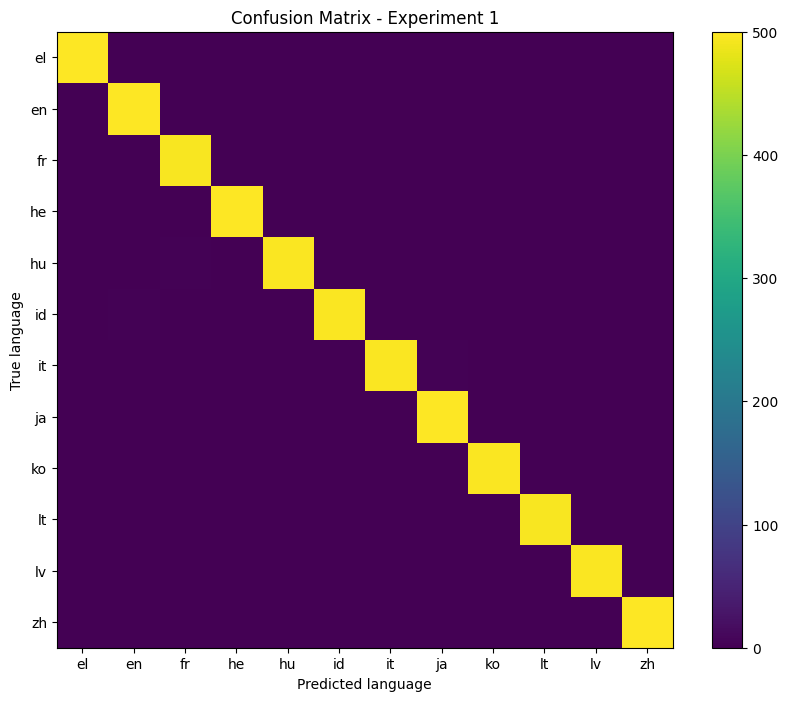

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

language_names = [
    "el", "en", "fr", "he",
    "hu", "id", "it", "ja",
    "ko", "lt", "lv", "zh"
]

cm = confusion_matrix(
    experiment_1_results["labels"],
    experiment_1_results["predictions"]
)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(12), language_names)
plt.yticks(range(12), language_names)

plt.xlabel("Predicted language")
plt.ylabel("True language")
plt.title("Confusion Matrix - Experiment 1")

plt.show()


In [11]:
!git clone https://github.com/minadjordjevic/Language-Classification.git

Cloning into 'Language-Classification'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 70 (delta 33), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 152.49 KiB | 2.88 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [12]:
%cd Language-Classification

/content/Language-Classification


In [13]:
from src.utils import set_seed
from src.models import LanguageClassifier

In [16]:
!ls src

data.py     experiment.py  preprocessing.py  train.py
dataset.py  models.py	   __pycache__	     utils.py


In [18]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [19]:
from src.utils import set_seed
from src.models import LanguageClassifier
from src.experiment import run_experiment

print("Moduli uspešno učitani!")

Moduli uspešno učitani!


In [24]:
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/train.py -O /content/src/train.py
!wget -q https://raw.githubusercontent.com/minadjordjevic/Language-Classification/main/src/experiment.py -O /content/src/experiment.py

print("train.py i experiment.py ažurirani.")

/content/src/train.py: No such file or directory
/content/src/experiment.py: No such file or directory
train.py i experiment.py ažurirani.


In [29]:
!pip install -r requirements.txt

In [33]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer uspešno učitan.")
print("Veličina vokabulara:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Tokenizer uspešno učitan.
Veličina vokabulara: 119547


In [40]:
from src.data import load_language_data
from src.preprocessing import create_dataframe, create_train_val_test_split

DATA_PATH = "/content/drive/MyDrive/vip/vip"

records = load_language_data(
    data_path=DATA_PATH,
    samples_per_language=5000,
    seed=42
)

df = create_dataframe(records)

train_df, val_df, test_df = create_train_val_test_split(
    df,
    test_size=0.10,
    validation_size=0.10,
    random_state=42
)

print("Raw:", len(records))
print("Clean:", len(df))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Raw: 60000
Clean: 59864
Train: 47890
Validation: 5987
Test: 5987


In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

label_encoder.fit(df["language"])

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label"] = label_encoder.transform(train_df["language"])
val_df["label"] = label_encoder.transform(val_df["language"])
test_df["label"] = label_encoder.transform(test_df["language"])

print("Broj klasa:", len(label_encoder.classes_))
print("Klase:", list(label_encoder.classes_))

Broj klasa: 12
Klase: ['el', 'en', 'fr', 'he', 'hu', 'id', 'it', 'ja', 'ko', 'lt', 'lv', 'zh']


In [42]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer uspešno učitan.")
print("Veličina vokabulara:", tokenizer.vocab_size)

Tokenizer uspešno učitan.
Veličina vokabulara: 119547


In [43]:
from src.dataset import LanguageDataset
from torch.utils.data import DataLoader

MAX_LENGTH = 128
BATCH_SIZE = 16

train_dataset = LanguageDataset(
    train_df["text"],
    train_df["label"],
    tokenizer,
    MAX_LENGTH
)

val_dataset = LanguageDataset(
    val_df["text"],
    val_df["label"],
    tokenizer,
    MAX_LENGTH
)

test_dataset = LanguageDataset(
    test_df["text"],
    test_df["label"],
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2994
Validation batches: 375
Test batches: 375


In [44]:
import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [45]:
from src.utils import set_seed
from src.experiment import run_experiment

set_seed(42)

experiment_2_model, experiment_2_results = run_experiment(
    experiment_name="experiment_2_learning_rate",
    model_name="bert-base-multilingual-cased",
    num_classes=12,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=DEVICE,
    learning_rate=1e-5,
    dropout=0.1,
    epochs=2,
)

print("\nExperiment 2 završen.")
print(experiment_2_results)

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026/08/26 22:01:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/26 22:01:26 INFO mlflow.store.db.utils: Updating database tables
2026/08/26 22:01:28 INFO mlflow.tracking.fluent: Experiment with name 'Language-Class

Epoch 1:   0%|          | 0/2994 [00:00<?, ?it/s]

Epoch 1/2 | Train Loss: 0.0434 | Train Acc: 0.9909 | Val Loss: 0.0097 | Val Acc: 0.9985 | Val F1: 0.9985


Epoch 2:   0%|          | 0/2994 [00:00<?, ?it/s]

Epoch 2/2 | Train Loss: 0.0055 | Train Acc: 0.9990 | Val Loss: 0.0091 | Val Acc: 0.9983 | Val F1: 0.9983

Test results:
Accuracy: 0.9985
F1: 0.9985
Training time: 2294.01s
Inference time: 43.37s

Experiment 2 završen.
{'loss': 0.006061617071197058, 'accuracy': 0.9984967429430432, 'f1': 0.9984953048434034, 'time': 43.36874294281006, 'predictions': [np.int64(3), np.int64(10), np.int64(6), np.int64(8), np.int64(5), np.int64(3), np.int64(2), np.int64(9), np.int64(8), np.int64(7), np.int64(10), np.int64(11), np.int64(10), np.int64(1), np.int64(11), np.int64(2), np.int64(0), np.int64(9), np.int64(11), np.int64(8), np.int64(6), np.int64(11), np.int64(1), np.int64(7), np.int64(6), np.int64(8), np.int64(5), np.int64(5), np.int64(10), np.int64(11), np.int64(5), np.int64(5), np.int64(10), np.int64(2), np.int64(8), np.int64(3), np.int64(2), np.int64(4), np.int64(10), np.int64(11), np.int64(11), np.int64(9), np.int64(7), np.int64(3), np.int64(5), np.int64(7), np.int64(4), np.int64(0), np.int64(4), 

In [50]:
runs = mlflow.search_runs(
    experiment_ids=["1"]
)

print(
    runs[
        [
            "run_id",
            "tags.mlflow.runName",
            "params.learning_rate",
            "params.dropout",
            "params.epochs",
            "metrics.test_accuracy",
            "metrics.test_f1",
            "metrics.test_loss",
            "metrics.training_time_seconds",
            "metrics.inference_time_seconds"
        ]
    ].to_string(index=False)
)

                          run_id        tags.mlflow.runName params.learning_rate params.dropout params.epochs  metrics.test_accuracy  metrics.test_f1  metrics.test_loss  metrics.training_time_seconds  metrics.inference_time_seconds
a9ac09759ca546e48cf211fc13a46930 experiment_2_learning_rate                1e-05            0.1             2               0.998497         0.998495           0.006062                    2294.008331                       43.368743
